## Overview

Dataloader Constructor for CNN GRU from local .nc file

seperated into

-Train, Validation, Test

-Season (Spring,Summer,Autumn, Winter)

-Recent or Past Seasons for training


----
## Data:

-2D Space - Timeseries

-predicting 1 feature out of 7 variables

-Forecasting 1 timestep (not the following)

-------
Peter Resch, 5.6.

In [1]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
import os
from pathlib import Path

import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

import xarray as xr

from my_dataloader_module import TimeseriesDatasetPipeline, TimeseriesPyTorchDataset

rSeed=42

SavePlots = False

## Loading Data

In [2]:
folder="../../../datasets/small_grid"
!cd {folder} && ls

 dataloaders				 grid-timeseries_sel_vars_2017.grib.nc
 grid-timeseries_sel_vars_1950.grib	 grid-timeseries_sel_vars_2018.grib
 grid-timeseries_sel_vars_1950.grib.nc	 grid-timeseries_sel_vars_2018.grib.nc
 grid-timeseries_sel_vars_1960.grib	 grid-timeseries_sel_vars_2019.grib
 grid-timeseries_sel_vars_1960.grib.nc	 grid-timeseries_sel_vars_2019.grib.nc
 grid-timeseries_sel_vars_1970.grib	 grid-timeseries_sel_vars_2020.grib
 grid-timeseries_sel_vars_1970.grib.nc	 grid-timeseries_sel_vars_2020.grib.nc
 grid-timeseries_sel_vars_1980.grib	 grid-timeseries_sel_vars_2021.grib
 grid-timeseries_sel_vars_1980.grib.nc	 grid-timeseries_sel_vars_2021.grib.nc
 grid-timeseries_sel_vars_1990.grib	 grid-timeseries_sel_vars_2022.grib
 grid-timeseries_sel_vars_1990.grib.nc	 grid-timeseries_sel_vars_2022.grib.nc
 grid-timeseries_sel_vars_2000.grib	 grid-timeseries_sel_vars_2023.grib
 grid-timeseries_sel_vars_2000.grib.nc	 grid-timeseries_sel_vars_2023.grib.nc
 grid-timeseries_sel_vars_2010.grib	 grid-tim

## Creating Train and Validation Dataloaders

In [ ]:
#-------------------------------
#select timeframe
years = [str(year) for year in range(2015,2025)]#recent: range (2015,2025), past:(1950, 2015), test:2025
#years=["2025"]
past="recent_"#"past_"#
#-------------------------------




filelist = [p.name for p in Path(folder).iterdir() if p.is_file()]
#clean filelist, let only .nc files
filelist = [f for f in filelist if f.endswith('.nc')]
filelist.sort()

print(years)
#filter the filelist to only include files for the selected years
filelist = [filename for filename in filelist if any(year in filename for year in years)]
print(filelist)
#filter the filelist to only include files without ssrd in the name
filelist = [filename for filename in filelist if "ssrd" not in filename]
print(filelist)

# Open the NetCDF files using xarray
ds={}
for filename in filelist:
    year = filename.split("_")[3]  # Extract the year from the filename
    ds[year]= xr.open_dataset(folder + "/" + filename)
    ds[year] = xr.decode_cf(ds[year])
    ds[year] = ds[year].assign_coords(time=pd.to_datetime(ds[year].time.values))
ds.keys()
#combining the dict datasets into one xarray dataset
ds_combined = xr.concat([ds[year] for year in ds.keys()], dim='time')
min_time = pd.to_datetime(ds_combined.time.min().values)
print(ds_combined.data_vars)


#splitting into seasons
seasons={"spring": "MAM", "summer": "JJA", "autumn": "SON", "winter": "DJF"}
ds_seasons = {}
for season, code in seasons.items():
    ds_seasons[season] = ds_combined.sel(time=ds_combined['time.season'] == code)

['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
['grid-timeseries_sel_vars_2015.grib.nc', 'grid-timeseries_sel_vars_2016.grib.nc', 'grid-timeseries_sel_vars_2017.grib.nc', 'grid-timeseries_sel_vars_2018.grib.nc', 'grid-timeseries_sel_vars_2019.grib.nc', 'grid-timeseries_sel_vars_2020.grib.nc', 'grid-timeseries_sel_vars_2021.grib.nc', 'grid-timeseries_sel_vars_2022.grib.nc', 'grid-timeseries_sel_vars_2023.grib.nc', 'grid-timeseries_sel_vars_2024.grib.nc']
['grid-timeseries_sel_vars_2015.grib.nc', 'grid-timeseries_sel_vars_2016.grib.nc', 'grid-timeseries_sel_vars_2017.grib.nc', 'grid-timeseries_sel_vars_2018.grib.nc', 'grid-timeseries_sel_vars_2019.grib.nc', 'grid-timeseries_sel_vars_2020.grib.nc', 'grid-timeseries_sel_vars_2021.grib.nc', 'grid-timeseries_sel_vars_2022.grib.nc', 'grid-timeseries_sel_vars_2023.grib.nc', 'grid-timeseries_sel_vars_2024.grib.nc']
Data variables:
    10u      (time, lat, lon) float32 9MB 7.11 6.43 5.352 ... 9.848 10.36 10.14
 

In [4]:
ds.keys()
ds["2020.grib.nc"]

<xarray.Dataset> Size: 6MB
Dimensions:  (time: 8784, lat: 5, lon: 5)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2020-01-01 ... 2020-12-31T23:00:00
  * lat      (lat) float64 40B 56.0 55.75 55.5 55.25 55.0
  * lon      (lon) float64 40B 12.0 12.25 12.5 12.75 13.0
Data variables:
    10u      (time, lat, lon) float32 878kB ...
    10v      (time, lat, lon) float32 878kB ...
    2t       (time, lat, lon) float32 878kB ...
    sp       (time, lat, lon) float32 878kB ...
    tp       (time, lat, lon) float32 878kB ...
    ssrd     (time, lat, lon) float32 878kB ...
    tcc      (time, lat, lon) float32 878kB ...
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Fri Jun 05 17:47:17 2026: cdo -f nc copy grid-timeseries_se...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [5]:
def save_idx_list(season,list_to_save, filename):
    # Save the list to a text file
    with open(filename, 'w') as f:
        for item in list_to_save:
            f.write(f"{season},{item}\n")

In [ ]:
#if dataloaders are not already created, create them and save for later use
folder_path = folder + "/dataloaders/"
batch_size=64
lag_selection=[0, 24, 48, 60, 66, 69, 71]
validate_ratio=0.20
target_var=4
forecast_horizon=1

print(ds_combined.data_vars)
print("-"*10,"Target selected:", list(ds_combined.data_vars)[target_var],"-"*10)

i=0
scaler_set={}
scaler_y={}

for season in ds_seasons.keys():
    i=i+1
    if not (os.path.exists(folder_path +past+season+ "_dataloader_train.pt") and os.path.exists(folder_path + past+season + "_dataloader_val.pt")):
        print("Dataloaders not found. Creating and saving dataloaders...")

        pipeline= TimeseriesDatasetPipeline(ds_seasons[season], lag_selection=lag_selection, forecast_horizon=forecast_horizon, forecast_var=target_var)
        dataloader_train,dataloader_val,skipped_idx_list_train,skipped_idx_list_val,sc_set,sc_y=pipeline.to_scaled_pytorch_train_test_dataloaders(batch_size=batch_size, test_size=validate_ratio, random_state=i)
        scaler_set[season]=sc_set
        scaler_y[season]=sc_y

        #saving scalers for later use
        torch.save(scaler_set, folder_path + past+season + "scaler_set.pt")
        torch.save(scaler_y, folder_path + past+season + "scaler_y.pt")

        #saving dataloaders for later use
        torch.save(dataloader_train, folder_path +past+season+ "_dataloader_train.pt")
        torch.save(dataloader_val, folder_path + past+season + "_dataloader_val.pt")

        save_idx_list(season, skipped_idx_list_train, folder_path + past + "skipped_idx_train.csv")
        save_idx_list(season, skipped_idx_list_val, folder_path + past+ "skipped_idx_val.csv")

        print(season + " dataloaders and skipped indices saved successfully.\n")

    else:
        print("Dataloaders already exist.")
        
print("All dataloaders are ready for use.")

Data variables:
    10u      (time, lat, lon) float32 9MB 7.11 6.43 5.352 ... 9.848 10.36 10.14
    10v      (time, lat, lon) float32 9MB 1.532 1.116 0.6305 ... 10.36 10.17
    2t       (time, lat, lon) float32 9MB 277.8 277.7 277.5 ... 278.1 278.1
    sp       (time, lat, lon) float32 9MB 1.026e+05 1.025e+05 ... 1.008e+05
    tp       (time, lat, lon) float32 9MB 1.335e-05 8.583e-06 ... 1.907e-05
    ssrd     (time, lat, lon) float32 9MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    tcc      (time, lat, lon) float32 9MB 0.896 0.9568 1.0 1.0 ... 1.0 1.0 1.0
---------- Target selected: tp ----------
Dataloaders not found. Creating and saving dataloaders...
Data prepared with shape: (22080, 7, 5, 5)
skipped number of indices: 510 out of 17606 total indices.
X: (17096, 7, 7, 5, 5) <class 'numpy.ndarray'>
y: (17096, 1, 5, 5) <class 'numpy.ndarray'>
skipped number of indices: 148 out of 4402 total indices.
X: (4254, 7, 7, 5, 5) <class 'numpy.ndarray'>
y: (4254, 1, 5, 5) <class 'numpy.ndarray'>
sp

In [ ]:
raise NotImplementedError("Dataloaders created and saved.")

In [ ]:
'''#Testing
lag_selection=[0, 24, 48, 60, 66, 69, 71]
lag_selection=[0, 2,3]
pipeline = TimeseriesDatasetPipeline(ds_seasons['summer'], lag_selection=lag_selection, forecast_horizon=1)
idxlist=[1, 2, 3, 4]#just a test list of indices
X,y=pipeline.create_windowed_dataset_from_idxlist(idxlist)

#X[0,0,0,:].shape#25
#X[0,0,0]
X.shape#(4, 3, 7, 5, 5)

print()
X_sc=pipeline.scale_X(X)
y_sc=pipeline.scale_y(y)
X_sc[1].shape

X_sc=pipeline.scale_X(X,X_sc[1])

tr,te=pipeline.create_random_train_test_split_idx(test_size=0.5)
tr
'''


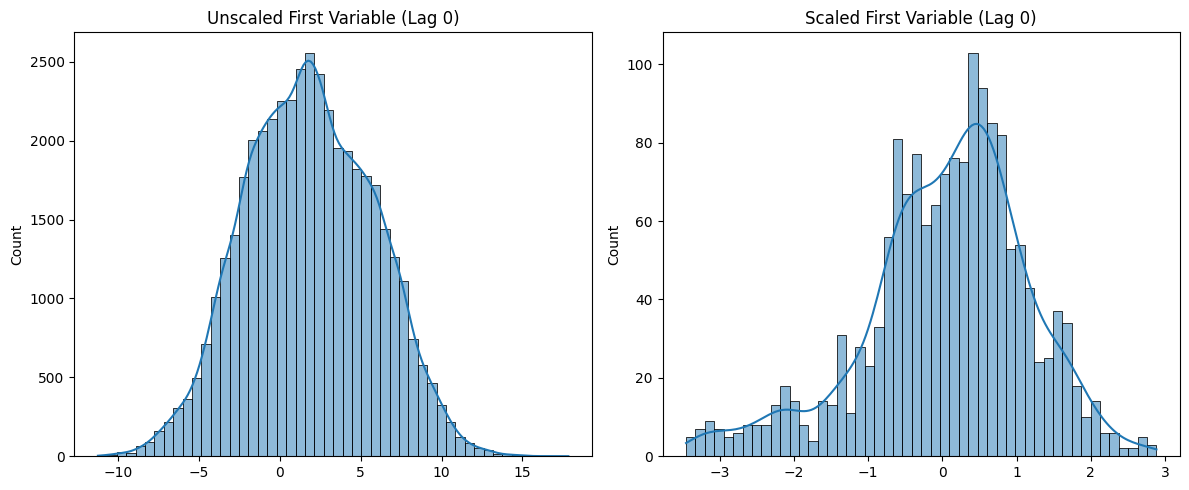

In [190]:
#Histogram of first variable scaled and unscaled for training dataloader
X_train, _ = next(iter(dataloader_train))
X_train_unscaled = pipeline.data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_train_unscaled[:, 0, 0, :].flatten(), bins=50, kde=True)
plt.title("Unscaled First Variable (Lag 0)")
plt.subplot(1, 2, 2)
sns.histplot(X_train[:, 0, 0, :].flatten(), bins=50, kde=True)
plt.title("Scaled First Variable (Lag 0)")
plt.tight_layout()

## Creating Test Dataloader

In [ ]:
#Test dataset
folder_path = folder + "/dataloaders/"
batch_size=64
lag_selection=[0, 24, 48, 60, 66, 69, 71]
validate_ratio=0.20
target_var=4
forecast_horizon=1

print(ds_combined.data_vars)
print("-"*10,"Target selected:", list(ds_combined.data_vars)[target_var],"-"*10)


for season in ds_seasons.keys():
    scaler_set[season]
    if not (os.path.exists(folder_path + "now"+ season + "_dataloader_test.pt")):
        print("Dataloaders not found. Creating and saving dataloaders...")

        pipeline_test = TimeseriesDatasetPipeline(ds_seasons[season], lag_selection=lag_selection, forecast_horizon=forecast_horizon, forecast_var=target_var)
        dataloader_test,skipped_idx_list_test,_,_ = pipeline_test.to_scaled_pytorch_dataloader(batch_size=batch_size, shuffle=False,scaler_set=scaler_set[season], scaler_y=scaler_y[season])

        #saving dataloaders for later use
        torch.save(dataloader_test, folder_path + "now_"+ season + "_dataloader_test.pt")
        save_idx_list(season, skipped_idx_list_test, folder_path + "now_skipped_idx_test.csv")
        print(season + " dataloaders saved successfully.")

Data variables:
    10u      (time, lat, lon) float32 9MB 7.11 6.43 5.352 ... 9.848 10.36 10.14
    10v      (time, lat, lon) float32 9MB 1.532 1.116 0.6305 ... 10.36 10.17
    2t       (time, lat, lon) float32 9MB 277.8 277.7 277.5 ... 278.1 278.1
    sp       (time, lat, lon) float32 9MB 1.026e+05 1.025e+05 ... 1.008e+05
    tp       (time, lat, lon) float32 9MB 1.335e-05 8.583e-06 ... 1.907e-05
    ssrd     (time, lat, lon) float32 9MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    tcc      (time, lat, lon) float32 9MB 0.896 0.9568 1.0 1.0 ... 1.0 1.0 1.0
---------- Target selected: tp ----------
Dataloaders not found. Creating and saving dataloaders...


Data prepared with shape: (22080, 7, 5, 5)
skipped number of indices: 658 out of 22008 total indices.
X: (21350, 7, 7, 5, 5) <class 'numpy.ndarray'>
y: (21350, 1, 5, 5) <class 'numpy.ndarray'>
spring dataloaders saved successfully.
Dataloaders not found. Creating and saving dataloaders...
Data prepared with shape: (22080, 7, 5, 5)
skipped number of indices: 658 out of 22008 total indices.
X: (21350, 7, 7, 5, 5) <class 'numpy.ndarray'>
y: (21350, 1, 5, 5) <class 'numpy.ndarray'>
summer dataloaders saved successfully.
Dataloaders not found. Creating and saving dataloaders...
Data prepared with shape: (21840, 7, 5, 5)
skipped number of indices: 658 out of 21768 total indices.
X: (21110, 7, 7, 5, 5) <class 'numpy.ndarray'>
y: (21110, 1, 5, 5) <class 'numpy.ndarray'>
autumn dataloaders saved successfully.
Dataloaders not found. Creating and saving dataloaders...
Data prepared with shape: (21672, 7, 5, 5)
skipped number of indices: 731 out of 21600 total indices.
X: (20869, 7, 7, 5, 5) <clas